# TP 17 - Entiers multi-précision


!!! abstract Entier multi-précision
Un entier multi-précision (ou arbitrary precision integer) est un entier dont :
- la taille mémoire s’adapte automatiquement à la valeur stockée
- il n’y a pas de borne fixe (en dehors des limites mémoire de la machine)

Sous Python, un entier est représenté comme :
+ un signe
+ une liste de "chiffres"
!!!

L'objectif de ce TP est de recoder les opérations arithmétique de base pour les entiers multiprécisions en base 10.

## Exercice 1 : Outils
!!! question Question 1
Écrire une fonction `int_vers_liste(n: int) -> list[int]` qui convertit un entier naturel `n` en une liste de ses termes dans le même ordre.
!!!

In [1]:
def int_vers_liste(n):
    assert n >= 0, "n doit être un entier natuel"
    # on gère le cas 0
    if n == 0 :
        return [0]
    l = []
    while n != 0:
        l.append(n%10)
        n = n//10
    # on renverse le résultat 
    return l[::-1]

In [2]:
print(int_vers_liste(1234)) #[1, 2, 3, 4]

[1, 2, 3, 4]


In [3]:
print(int_vers_liste(0)) #[0]

[0]


!!! question Question 2
Écrire une fonction `liste_vers_int(l: list[int]) -> int` qui convertit une liste `l` d'entier en un entier naturel `n` tel que `liste_vers_int(int_vers_liste(n))==n`.
!!!

In [4]:
def liste_vers_int(l):
    res = 0
    for x in l:
        res = res * 10
        res += x
    return res

In [7]:
print(liste_vers_int([1,2,3,4])) # 1234
print(liste_vers_int([0])) # 0

1234
0


In [8]:
print(liste_vers_int(int_vers_liste(12345)) == 12345) # True

True


!!! question Question 3
Écrire une fonction `complement(l1: list[int], l2: list[int]) -> (list[int], list[int])` qui prend en argument deux listes `l1` et `l2` d’entiers compris entre 0 et 9 de tailles quelconques et qui renvoie les deux listes `l1` et `l2` dont la taille est identique, égale à la plus grande des tailles initiales de
`l1` et `l2`, la plus petite étant complétée de 0 à gauche.
!!!

In [9]:
def complement(l1, l2):
    if len(l1) == len(l2):
        return (l1, l2)
    elif len(l1) < len(l2):
        return ([0 for _ in range(len(l2)-len(l1))]+l1, l2)
    else:
        return (l1, [0 for _ in range(len(l1)-len(l2))]+l2)
        

In [10]:
print(complement([1,2,3,4], [5,6])) #([1, 2, 3, 4], [0, 0, 5, 6])

([1, 2, 3, 4], [0, 0, 5, 6])


In [11]:
print(complement([1,2], [3,4,5,6])) #([0, 0, 1, 2], [3, 4, 5, 6])

([0, 0, 1, 2], [3, 4, 5, 6])


In [12]:
print(complement([1,2], [3,4])) #([1, 2], [3, 4])

([1, 2], [3, 4])


## Exercice 2 : Addition
Nous allons proposer une fonction qui réalise l’addition de deux entiers naturels `x` et `y` en se basant sur le principe de calcul vu à l’école primaire, en n’oubliant pas les retenues.
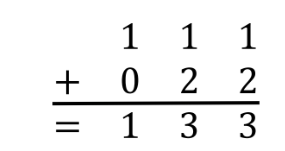

!!! question Question 4
Écrire une fonction `addition(x: int, y: int) -> int` qui réalise la somme de `x` et `y`.
!!!

In [13]:
def addition(x, y):
    # on sépare chaque chiffres
    lx = int_vers_liste(x)
    ly = int_vers_liste(y)
    
    # on complète pour qu'il fasse la même taille
    lx, ly = complement(lx, ly)
    
    # on retourne les listes pour parcourir de droite à gauche
    lx, ly = lx[::-1], ly[::-1]
    
    # initialisation du résultat et de la retenue
    res = []
    retenue = 0
    
    for i in range(len(lx)):
        r = lx[i] + ly[i] + retenue
        if r < 10 :         # cas sans retenue
            retenue = 0
        else:               # cas avec
            retenue = 1
        res.append(r%10)
    # ajout du 1 supplémentaire en cas de retenue sur la fin
    if retenue != 0 : 
        res.append(retenue)
    return liste_vers_int(res[::-1])
        

In [14]:
print(addition(11,99)) #110

110


!!! question Question 5
Quel est la complexité temporelle de votre fonction `addition()`. Justifier.
!!!

!!! question Question 6
Écrire une fonction `def addition_liste(l: list[int]) -> int` qui additionne une liste d'entier en utilisant votre fonction adition.
!!!

In [34]:
def addition_liste(l):
    assert len(l) > 0, "il faut au moins un entier dans l" 
    if len(l) == 1:
        return l[0]
    res = addition(l[0], l[1])
    for i in range(2, len(l)):
        res = addition(res, l[i])
    return res

In [35]:
print(addition_liste([44,65,99])) #208

208


## Exercice 3 : Multiplication

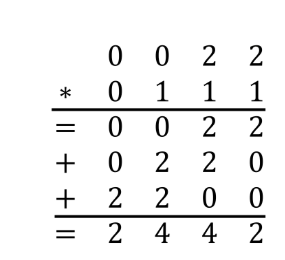
!!! question Question 7
Ecrire une fonction `multiplication(x,y)` qui réalise le produit de `x` et `y` comme proposé et renvoie le résultat.
!!!

In [69]:
def multiplication(x, y):
    # on sépare chaque chiffres
    lx = int_vers_liste(x)
    ly = int_vers_liste(y)
    
    # on retourne les listes pour parcourir de droite à gauche
    lx, ly = lx[::-1], ly[::-1]
    
    # initialisation de la retenue et du la liste des nombre à additionner
    liste_addition = []
    retenue = 0
    for i in range(len(ly)):
        # on comble de 0 en fonction de la puissance du chiffre dans ly
        nombre_a_additionner = [0 for _ in range(i)]
        for j in range(len(lx)):
            r = ly[i] * lx[j] + retenue
            if r < 10 :
                retenue = 0
            else:
                retenue = r//10
            nombre_a_additionner.append(r%10)
        # si on a une retenue à la fin on l'ajoute et on remet la retenue à 0
        if retenue != 0:
            nombre_a_additionner.append(retenue)
            retenue = 0
            
        liste_addition.append(liste_vers_int(nombre_a_additionner[::-1]))
    return addition_liste(liste_addition)
            
    

In [70]:
print(multiplication(22,111)) #2442

2442


In [71]:
print(multiplication(66,44)) #2904

2904


!!! question Question 8
Donner la complexité temporelle de votre fonction `multiplication()`. Justifier.
!!!